# Reaching system sizes up to 10000000 atoms on a single-core laptop

Because the KPM/Chebyshev expansion never diagonalizes the Hamiltonian -- only sparse
matrix-vector products, whose cost per site is fixed -- its cost scales *linearly* with system
size rather than the cubic scaling of exact diagonalization. Below, the same `h.get_dos(mode="KPM")`
call from the first notebook of this section is timed on sparse 1D chains from a thousand to
several million sites, on a single core, showing the near-linear scaling that makes multi-million
atom systems tractable.

      1000 atoms:   0.00s
     10000 atoms:   0.02s


    100000 atoms:   0.27s


   1000000 atoms:   3.75s


   3000000 atoms:  11.56s


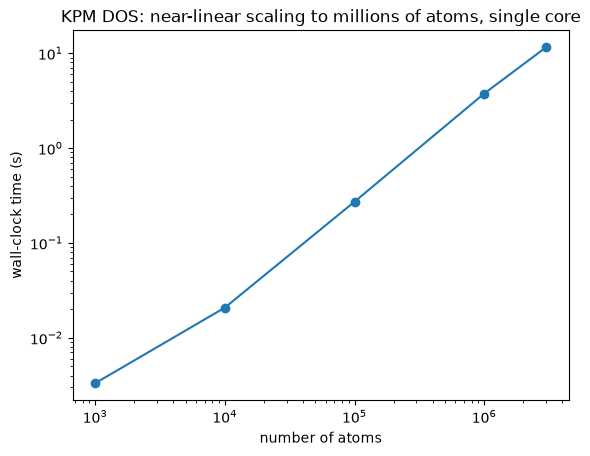

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
import time

# warm up numba's JIT compilation once, outside the timed loop below
_g0 = geometry.chain().get_supercell(100) ; _g0.dimensionality = 0
_g0.get_hamiltonian(is_sparse=True,has_spin=False).get_dos(mode="KPM",
        energies=np.linspace(-3,3,150),delta=5e-2,ntries=3)

sizes = [10**3,10**4,10**5,10**6,3*10**6]
times = []
for n in sizes:
    g = geometry.chain()
    g = g.get_supercell(n)
    g.dimensionality = 0
    h = g.get_hamiltonian(is_sparse=True,has_spin=False)
    t0 = time.time()
    x,y = h.get_dos(mode="KPM",energies=np.linspace(-3,3,150),delta=5e-2,ntries=3)
    dt = time.time()-t0
    times.append(dt)
    print(f"{n:>10d} atoms: {dt:6.2f}s")

plt.loglog(sizes,times,marker="o")
plt.xlabel("number of atoms") ; plt.ylabel("wall-clock time (s)")
plt.title("KPM DOS: near-linear scaling to millions of atoms, single core")
plt.show()